# K-Means: k Selection and Dataset Comparison

This notebook uses the from-scratch `KMeans` in `models/kmeans.py` to: 
1) Compare different values of `k` (number of clusters) and compute clustering metrics (ARI, AMI, silhouette, purity, inertia).
2) Compare the performance of KMeans on `results/fires_engineered_features.csv` (engineered/scaled) vs `results/fires_merged_all_features.csv` (original) using the same k-grid.

Notes: KMeans is distance-based and sensitive to feature scaling. We will scale the original dataset numeric features (StandardScaler) to make the comparison fair versus the engineered features (which are scaled). 

In [1]:
# Imports and setup
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (adjusted_rand_score, adjusted_mutual_info_score,
                             homogeneity_score, completeness_score, silhouette_score,
                             davies_bouldin_score, calinski_harabasz_score)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.style.use('seaborn-v0_8-darkgrid')

# Add models path and import custom KMeans
sys.path.insert(0, os.path.abspath('../'))
from models.kmeans import KMeans

# Dunn index function (min inter-cluster distance / max intra-cluster diameter)
def compute_dunn_index(X, labels):
    unique_clusters = np.unique(labels)
    # remove noise labels (-1) if present
    unique_clusters = unique_clusters[unique_clusters != -1] if len(unique_clusters) > 0 else unique_clusters
    if len(unique_clusters) < 2:
        return np.nan

    # compute cluster diameters (max pairwise distance within each cluster)
    max_diameter = 0.0
    for c in unique_clusters:
        pts = X[labels == c]
        if len(pts) <= 1:
            continue
        # pairwise distances (we can use numpy broadcasting)
        dists = np.linalg.norm(pts[:, None, :] - pts[None, :, :], axis=2)
        diam = dists.max()
        if diam > max_diameter:
            max_diameter = diam

    # compute min inter-cluster centroid distances
    centroids = []
    for c in unique_clusters:
        pts = X[labels == c]
        if len(pts) == 0:
            continue
        centroids.append(pts.mean(axis=0))
    centroids = np.array(centroids)
    inter_dists = np.linalg.norm(centroids[:, None, :] - centroids[None, :, :], axis=2)
    # set diagonal to inf to avoid zero distance to self
    np.fill_diagonal(inter_dists, np.inf)
    min_inter = inter_dists.min()

    if max_diameter == 0 or np.isinf(min_inter):
        return np.nan
    return min_inter / max_diameter

print('✅ Imports complete and custom KMeans is available')

✅ Imports complete and custom KMeans is available


In [2]:
# Load datasets
df_eng = pd.read_csv('../results/fires_engineered_features.csv')
df_orig = pd.read_csv('../results/fires_merged_all_features.csv')

print('Engineered:', df_eng.shape)
print(df_eng['class'].value_counts())
print('Original:', df_orig.shape)
print(df_orig['class'].value_counts())

Engineered: (7302, 23)
class
0    4017
1    3285
Name: count, dtype: int64
Original: (7302, 43)
class
0    4017
1    3285
Name: count, dtype: int64


## Prepare Features
- Engineered: already scaled & numeric features used.
- Original: select numeric-only columns, fill missing values, and scale features with StandardScaler for fair comparison.

In [3]:
# ENGINEERED dataset
X_eng = df_eng.drop(['longitude','latitude','class'], axis=1).values
y_eng = df_eng['class'].values

# ORIGINAL dataset - numeric only
X_orig_full = df_orig.drop(['longitude','latitude','class'], axis=1)
non_numeric = X_orig_full.select_dtypes(include=['object']).columns.tolist()
if non_numeric:
    print('Dropping non-numeric columns from original:', non_numeric)
    X_orig_full = X_orig_full.select_dtypes(include=[np.number])

# Fill missing values if any
if X_orig_full.isnull().sum().sum() > 0:
    X_orig_full = X_orig_full.fillna(X_orig_full.mean())

scaler = StandardScaler()
X_orig_scaled = scaler.fit_transform(X_orig_full.values)
y_orig = df_orig['class'].values

print('X_eng shape:', X_eng.shape)
print('X_orig_scaled shape:', X_orig_scaled.shape)

X_eng shape: (7302, 20)
X_orig_scaled shape: (7302, 40)


## Evaluate K values with Custom KMeans
We will test a range of k values and compute clustering metrics per k for each dataset.

In [4]:
def evaluate_k_grid(X, y, k_values, init='k-means++', random_state=42):
    results = []
    for k in k_values:
        model = KMeans(n_clusters=k, init=init, random_state=random_state)
        model.fit(X)
        labels = model.labels_
        inertia = float(model.inertia_) if hasattr(model, 'inertia_') else np.nan

        ari = adjusted_rand_score(y, labels)
        ami = adjusted_mutual_info_score(y, labels, average_method='arithmetic')
        hom = homogeneity_score(y, labels)
        comp = completeness_score(y, labels)

        # WCSS (Within-Cluster Sum of Squares) -> inertia from our KMeans implementation
        wcss = inertia

        # Davies-Bouldin Index and Calinski-Harabasz (only if >=2 clusters)
        try:
            if len(unique_clusters) >= 2:
                dbi = davies_bouldin_score(X, labels)
                ch = calinski_harabasz_score(X, labels)
            else:
                dbi = np.nan
                ch = np.nan
        except Exception:
            dbi = np.nan
            ch = np.nan

        # Dunn index
        dunn = compute_dunn_index(X, labels)

        # Purity: cluster-wise majority/ total
        unique_clusters = np.unique(labels)
        cluster_purities = []
        for c in unique_clusters:
            members = y[labels == c]
            if len(members) == 0:
                cluster_purities.append(0)
            else:
                cluster_purities.append(np.bincount(members.astype(int)).max())
        purity = np.sum(cluster_purities) / len(labels)

        try:
            if len(unique_clusters) >= 2:
                sil = silhouette_score(X, labels, metric='euclidean')
            else:
                sil = np.nan
        except Exception:
            sil = np.nan

        results.append({
            'k': k,
            'ARI': ari,
            'AMI': ami,
            'homogeneity': hom,
            'completeness': comp,
            'purity': purity,
            'silhouette': sil,
            'inertia': inertia,
            'WCSS': wcss,
            'DBI': dbi,
            'CH': ch,
            'Dunn': dunn
        })
    return pd.DataFrame(results)

k_values = [2, 3, 4, 5, 6, 8, 10]

print('Running K grid on Engineered dataset...')
results_eng = evaluate_k_grid(X_eng, y_eng, k_values)
print('Engineered results:')
display(results_eng)

print('Running K grid on Original (scaled) dataset...')
results_orig = evaluate_k_grid(X_orig_scaled, y_orig, k_values)
print('Original results:')
display(results_orig)

Running K grid on Engineered dataset...
Engineered results:
Engineered results:


,k,ARI,AMI,homogeneity,completeness,purity,silhouette,inertia,WCSS,DBI,CH,Dunn
0,2,0.157158,0.122444,0.122863,0.122202,0.698302,0.296190,98291.080141,98291.080141,NaN,NaN,0.313370
1,3,0.138424,0.114348,0.145633,0.094315,0.720488,0.261288,82455.087780,82455.087780,1.353650,2814.297376,0.276003
2,4,0.127911,0.116741,0.174774,0.087839,0.714873,0.234500,71732.250243,71732.250243,1.513872,2520.009972,0.225475
3,5,0.098058,0.114353,0.188426,0.082305,0.717475,0.226066,66651.148953,66651.148953,1.549892,2172.882445,0.202901
4,6,0.089954,0.105319,0.183561,0.074095,0.712545,0.239727,62788.381133,62788.381133,1.483437,1934.765000,0.222258
5,8,0.057557,0.097607,0.193137,0.065592,0.711312,0.201907,55217.886471,55217.886471,1.514525,1713.876578,0.208905
6,10,0.054567,0.090012,0.189973,0.059313,0.710627,0.246538,46690.204634,46690.204634,1.291795,1724.032109,0.207092


Running K grid on Original (scaled) dataset...
Original results:
Original results:


,k,ARI,AMI,homogeneity,completeness,purity,silhouette,inertia,WCSS,DBI,CH,Dunn
0,2,0.104868,0.077969,0.078346,0.077778,0.662010,0.207548,232822.145628,232822.145628,NaN,NaN,0.277454
1,3,0.089278,0.066999,0.083585,0.056114,0.656943,0.224785,197577.556586,197577.556586,1.573785,1745.576133,0.247470
2,4,0.087445,0.084441,0.124381,0.064130,0.683374,0.223718,174722.995840,174722.995840,1.607913,1633.960491,0.275795
3,5,0.085576,0.080621,0.130488,0.058567,0.695426,0.208514,163957.657963,163957.657963,1.531162,1425.533796,0.247092
4,6,0.085581,0.080902,0.131654,0.058688,0.696111,0.209526,162935.945077,162935.945077,1.475114,1156.571098,0.247103
5,8,0.067627,0.076925,0.143306,0.052899,0.706245,0.236026,143318.442954,143318.442954,1.516107,1081.574285,0.254369
6,10,0.059370,0.072276,0.149152,0.048049,0.703780,0.240100,122609.840676,122609.840676,1.451395,1119.881474,0.206299


## Plot metrics vs K and compare datasets
We'll plot ARI, AMI, Silhouette & Purity for both datasets across the tested k values, plus inertia curves.

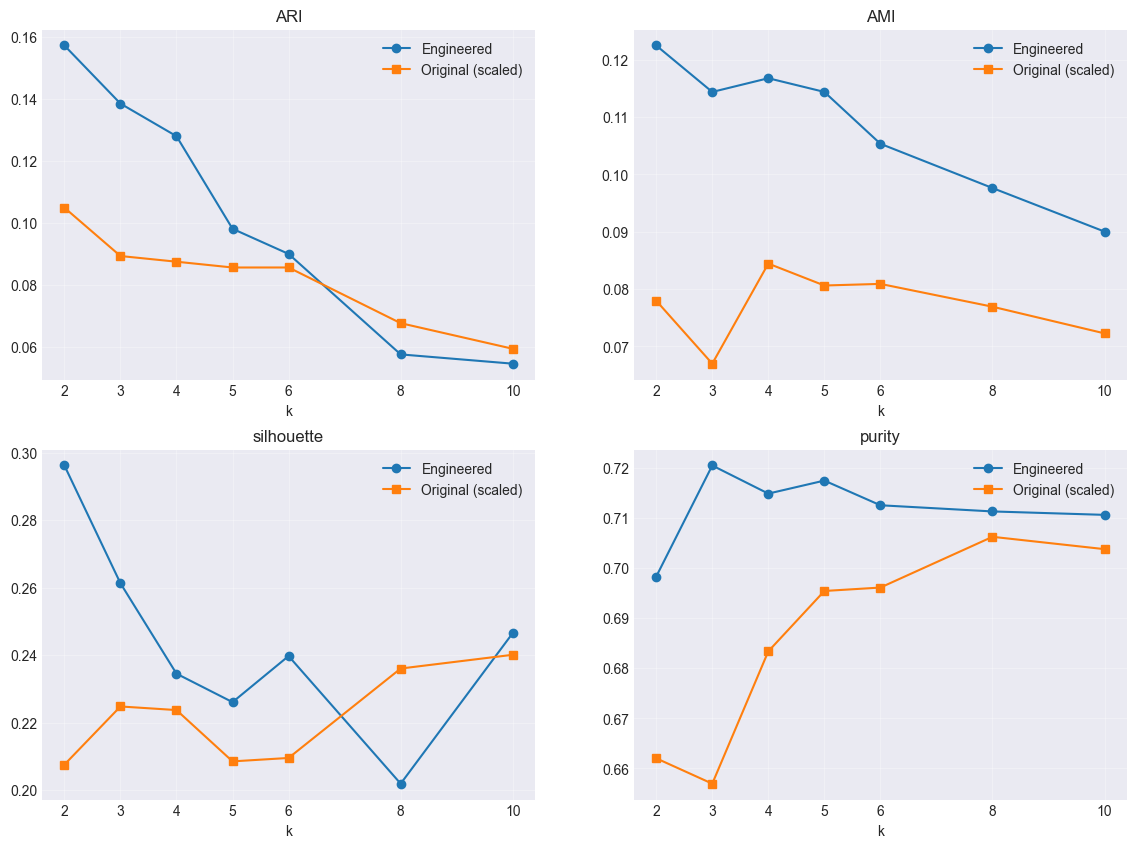

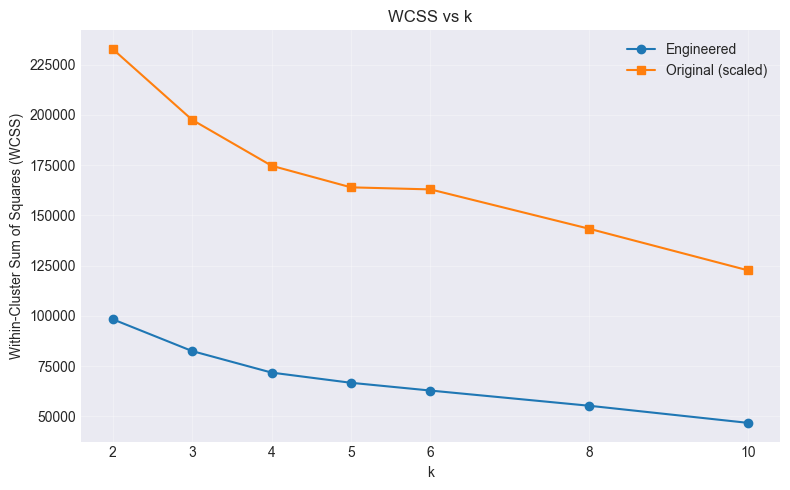

In [5]:
metrics_to_plot = ['ARI','AMI','silhouette','purity','WCSS','DBI','CH','Dunn']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
for i, m in enumerate(metrics_to_plot[:4]):
    axes[i].plot(results_eng['k'], results_eng[m], marker='o', label='Engineered')
    axes[i].plot(results_orig['k'], results_orig[m], marker='s', label='Original (scaled)')
    axes[i].set_title(m)
    axes[i].set_xlabel('k')
    axes[i].set_xticks(k_values)
    axes[i].legend()
    axes[i].grid(alpha=0.3)

# WCSS / Inertia plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(results_eng['k'], results_eng['WCSS'], marker='o', label='Engineered')
ax.plot(results_orig['k'], results_orig['WCSS'], marker='s', label='Original (scaled)')
ax.set_title('WCSS vs k')
ax.set_xlabel('k')
ax.set_xticks(k_values)
ax.set_ylabel('Within-Cluster Sum of Squares (WCSS)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Best K per Dataset and Metric
Determine the `k` that maximizes ARI, Silhouette, and Purity for each dataset.

In [6]:
def best_k_by_metric(df, metric):
    idx = df[metric].idxmax()
    return df.loc[idx, 'k'], df.loc[idx, metric]

best_eng_ari = best_k_by_metric(results_eng, 'ARI')
best_eng_sil = best_k_by_metric(results_eng, 'silhouette')
best_eng_pur = best_k_by_metric(results_eng, 'purity')

best_orig_ari = best_k_by_metric(results_orig, 'ARI')
best_orig_sil = best_k_by_metric(results_orig, 'silhouette')
best_orig_pur = best_k_by_metric(results_orig, 'purity')

print('Engineered bests (k, metric):')
print('ARI:', best_eng_ari)
print('Silhouette:', best_eng_sil)
print('Purity:', best_eng_pur)

print('Original (scaled) bests (k, metric):')
print('ARI:', best_orig_ari)
print('Silhouette:', best_orig_sil)
print('Purity:', best_orig_pur)

Engineered bests (k, metric):
ARI: (2, 0.15715826920060438)
Silhouette: (2, 0.2961899668684769)
Purity: (3, 0.7204875376609148)
Original (scaled) bests (k, metric):
ARI: (2, 0.10486798691979461)
Silhouette: (10, 0.2401003186716153)
Purity: (8, 0.7062448644207067)


## Visualize cluster assignments for a chosen k (for both datasets)
Plot 2D scatter projections (using PCA) to visualize clusters for the selected k values (best by ARI) for each dataset.

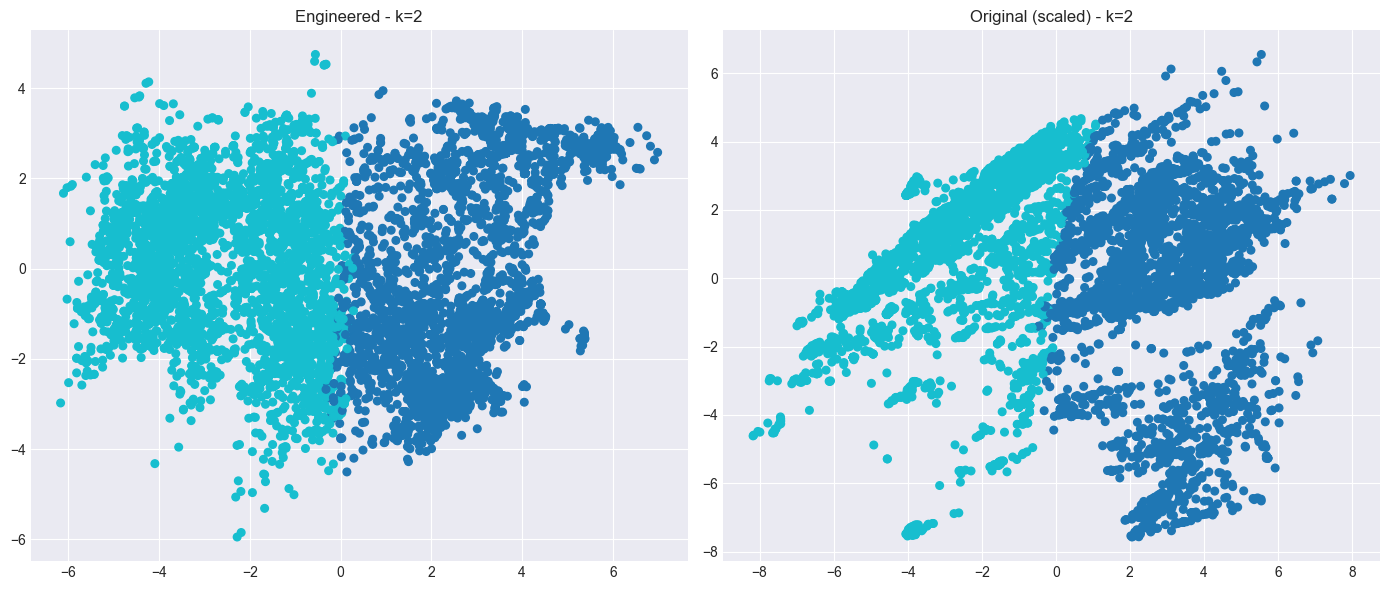

In [7]:
from sklearn.decomposition import PCA

# Choose k to visualize (best by ARI)
k_vis_eng = int(best_eng_ari[0])
k_vis_orig = int(best_orig_ari[0])

pca = PCA(n_components=2, random_state=42)
X_eng_2d = pca.fit_transform(X_eng)
X_orig_2d = pca.fit_transform(X_orig_scaled)

# Fit KMeans for both datasets with chosen k
model_eng = KMeans(n_clusters=k_vis_eng, random_state=42)
model_eng.fit(X_eng)
labels_eng = model_eng.labels_

model_orig = KMeans(n_clusters=k_vis_orig, random_state=42)
model_orig.fit(X_orig_scaled)
labels_orig = model_orig.labels_

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(X_eng_2d[:,0], X_eng_2d[:,1], c=labels_eng, cmap='tab10', s=30)
axes[0].set_title(f'Engineered - k={k_vis_eng}')
axes[1].scatter(X_orig_2d[:,0], X_orig_2d[:,1], c=labels_orig, cmap='tab10', s=30)
axes[1].set_title(f'Original (scaled) - k={k_vis_orig}')
plt.tight_layout()
plt.show()

## test init='random' vs k-means++

In [8]:
# Compare init methods: 'random' vs 'k-means++'
# We'll test both on the engineered dataset for a few k values and compare stability & metrics

init_methods = ['random', 'k-means++']
k_test = [2, 3, 4, 5]
n_runs = 5  # multiple runs to assess stability

comparison_results = []

for init_method in init_methods:
    for k in k_test:
        run_ari = []
        run_sil = []
        run_inertia = []
        
        for run in range(n_runs):
            model = KMeans(n_clusters=k, init=init_method, random_state=42+run)
            model.fit(X_eng)
            labels = model.labels_
            
            ari = adjusted_rand_score(y_eng, labels)
            run_ari.append(ari)
            run_inertia.append(float(model.inertia_))
            
            unique_clusters = np.unique(labels)
            if len(unique_clusters) >= 2:
                sil = silhouette_score(X_eng, labels, metric='euclidean')
                run_sil.append(sil)
            else:
                run_sil.append(np.nan)
        
        comparison_results.append({
            'init': init_method,
            'k': k,
            'ARI_mean': np.mean(run_ari),
            'ARI_std': np.std(run_ari),
            'silhouette_mean': np.nanmean(run_sil),
            'silhouette_std': np.nanstd(run_sil),
            'inertia_mean': np.mean(run_inertia),
            'inertia_std': np.std(run_inertia)
        })

df_comparison = pd.DataFrame(comparison_results)
print('Init method comparison results (Engineered dataset):')
display(df_comparison)

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for init_method in init_methods:
    df_sub = df_comparison[df_comparison['init'] == init_method]
    marker = 'o' if init_method == 'k-means++' else 's'
    
    axes[0].errorbar(df_sub['k'], df_sub['ARI_mean'], yerr=df_sub['ARI_std'], 
                     marker=marker, label=init_method, capsize=5)
    axes[1].errorbar(df_sub['k'], df_sub['silhouette_mean'], yerr=df_sub['silhouette_std'], 
                     marker=marker, label=init_method, capsize=5)
    axes[2].errorbar(df_sub['k'], df_sub['inertia_mean'], yerr=df_sub['inertia_std'], 
                     marker=marker, label=init_method, capsize=5)

axes[0].set_title('ARI: random vs k-means++')
axes[0].set_xlabel('k')
axes[0].set_ylabel('ARI (mean ± std)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_title('Silhouette: random vs k-means++')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette (mean ± std)')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Compare init methods: 'random' vs 'k-means++'
# We'll test both on the engineered dataset for a few k values and compare stability & metrics

init_methods = ['random', 'k-means++']
k_test = [2, 3, 4, 5]
n_runs = 5  # multiple runs to assess stability

comparison_results = []

for init_method in init_methods:
    for k in k_test:
        run_ari = []
        run_sil = []
        run_inertia = []
        run_dbi = []
        run_ch = []
        run_dunn = []
        
        for run in range(n_runs):
            model = KMeans(n_clusters=k, init=init_method, random_state=42+run)
            model.fit(X_eng)
            labels = model.labels_
            
            ari = adjusted_rand_score(y_eng, labels)
            run_ari.append(ari)
            run_inertia.append(float(model.inertia_))
            
            unique_clusters = np.unique(labels)
            if len(unique_clusters) >= 2:
                sil = silhouette_score(X_eng, labels, metric='euclidean')
                run_sil.append(sil)
                try:
                    dbi_val = davies_bouldin_score(X_eng, labels)
                    ch_val = calinski_harabasz_score(X_eng, labels)
                except Exception:
                    dbi_val = np.nan
                    ch_val = np.nan
                run_dbi.append(dbi_val)
                run_ch.append(ch_val)
                dunn_val = compute_dunn_index(X_eng, labels)
                run_dunn.append(dunn_val)
            else:
                run_sil.append(np.nan)
                run_dbi.append(np.nan)
                run_ch.append(np.nan)
                run_dunn.append(np.nan)
        
        comparison_results.append({
            'init': init_method,
            'k': k,
            'ARI_mean': np.mean(run_ari),
            'ARI_std': np.std(run_ari),
            'silhouette_mean': np.nanmean(run_sil),
            'silhouette_std': np.nanstd(run_sil),
            'inertia_mean': np.mean(run_inertia),
            'inertia_std': np.std(run_inertia),
            'DBI_mean': np.nanmean(run_dbi) if len(run_dbi)>0 else np.nan,
            'DBI_std': np.nanstd(run_dbi) if len(run_dbi)>0 else np.nan,
            'CH_mean': np.nanmean(run_ch) if len(run_ch)>0 else np.nan,
            'CH_std': np.nanstd(run_ch) if len(run_ch)>0 else np.nan,
            'Dunn_mean': np.nanmean(run_dunn) if len(run_dunn)>0 else np.nan,
            'Dunn_std': np.nanstd(run_dunn) if len(run_dunn)>0 else np.nan
        })

df_comparison = pd.DataFrame(comparison_results)
print('Init method comparison results (Engineered dataset):')
display(df_comparison)

# Plot comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for init_method in init_methods:
    df_sub = df_comparison[df_comparison['init'] == init_method]
    marker = 'o' if init_method == 'k-means++' else 's'
    
    axes[0].errorbar(df_sub['k'], df_sub['ARI_mean'], yerr=df_sub['ARI_std'], 
                     marker=marker, label=init_method, capsize=5)
    axes[1].errorbar(df_sub['k'], df_sub['silhouette_mean'], yerr=df_sub['silhouette_std'], 
                     marker=marker, label=init_method, capsize=5)
    axes[2].errorbar(df_sub['k'], df_sub['inertia_mean'], yerr=df_sub['inertia_std'], 
                     marker=marker, label=init_method, capsize=5)
    axes[3].errorbar(df_sub['k'], df_sub['DBI_mean'], yerr=df_sub['DBI_std'], marker=marker, label=init_method, capsize=5)
    axes[4].errorbar(df_sub['k'], df_sub['CH_mean'], yerr=df_sub['CH_std'], marker=marker, label=init_method, capsize=5)
    axes[5].errorbar(df_sub['k'], df_sub['Dunn_mean'], yerr=df_sub['Dunn_std'], marker=marker, label=init_method, capsize=5)

axes[0].set_title('ARI: random vs k-means++')
axes[0].set_xlabel('k')
axes[0].set_ylabel('ARI (mean ± std)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_title('Silhouette: random vs k-means++')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette (mean ± std)')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].set_title('Inertia: random vs k-means++')
axes[2].set_xlabel('k')
axes[2].set_ylabel('Inertia (mean ± std)')
axes[2].legend()
axes[2].grid(alpha=0.3)

axes[3].set_title('DBI: random vs k-means++')
axes[3].set_xlabel('k')
axes[3].set_ylabel('DBI (mean ± std)')
axes[3].legend()
axes[3].grid(alpha=0.3)

axes[4].set_title('CH: random vs k-means++')
axes[4].set_xlabel('k')
axes[4].set_ylabel('CH (mean ± std)')
axes[4].legend()
axes[4].grid(alpha=0.3)

axes[5].set_title('Dunn: random vs k-means++')
axes[5].set_xlabel('k')
axes[5].set_ylabel('Dunn (mean ± std)')
axes[5].legend()
axes[5].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('
✅ Init method comparison complete: k-means++ typically shows better consistency and convergence')

SyntaxError: unterminated string literal (detected at line 198) (1803277751.py, line 198)